#               Nombre del docente            
#           Leonel andrés lópez arias
#
#
#             Nombre del estudiante
#           Ruben Dario Obando Mendez
#
#
#                  Asignatura
#     LENGUAJES DE PROGRAMACION PARA ANALITICA II



# Creacion y Evaluacion de Modelos de Prediccion Basados en Regresiones Lineales Multiples
---
**Caso de estudio Integrador — Consumo de carne de pollo (2000-2022)**

**Objetivo:** Predecir el consumo per capita de carne de pollo (Y) a partir de variables economicas
como el ingreso disponible, el precio del pollo y el precio del cerdo.

---

## Descripcion del problema

Un analista de datos esta estimando posibles predicciones frente a una base de datos historicos
en el area de la alimentacion. Los datos muestran el consumo de carne de pollo a lo largo del
tiempo entre los anos 2000 y 2022.

La empresa desea predecir diferentes valores de consumo por libras en estos anos que puedan
servir como referencia para encaminar sus decisiones de mercado en un futuro proximo.

## Variables del modelo

| Variable | Descripcion | Unidad |
|---|---|---|
| **Y** | Consumo per capita de carne de pollo | Libras por persona |
| **X2** | Ingreso per capita real disponible | Dolares por persona |
| **X3** | Precio real del pollo al menudeo | Centavos por libra |
| **X4** | Precio real del cerdo al menudeo | Centavos por libra |
| **X5** | Variable adicional del dataset | Unidades |

> **Nota sobre per capita:** El termino "per capita" viene del latin y significa "por persona".
> Indica que el valor ya fue dividido entre el total de la poblacion, lo que permite
> comparaciones justas entre diferentes anos sin importar el crecimiento demografico.


---
## 1. Importacion de Librerias

**¿Que hace esta celda?**
Cargamos todas las herramientas que vamos a necesitar a lo largo del notebook.
Es como abrir la caja de herramientas antes de ponerse a trabajar.
Cada libreria tiene un rol especifico:

- **pandas:** Maneja tablas de datos (como Excel pero en Python)
- **numpy:** Realiza calculos matematicos y operaciones con arrays
- **matplotlib / seaborn:** Dibuja todas las graficas del analisis
- **sklearn:** Contiene las herramientas para construir el modelo de regresion
- **warnings:** Silencia mensajes de advertencia que no son importantes


In [2]:
# Importacion de librerias necesarias para el analisis
import pandas as pd               # Manejo de datos en tablas (DataFrames)
import numpy as np                # Operaciones matematicas y arrays
import matplotlib.pyplot as plt   # Graficas basicas
import seaborn as sns             # Graficas estadisticas avanzadas
from sklearn.linear_model import LinearRegression   # Modelo de regresion lineal
from sklearn.model_selection import train_test_split # Division train/test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Metricas
import warnings
warnings.filterwarnings("ignore")

# Configuracion estetica de las graficas
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12

print("Librerias cargadas correctamente")
print("Versiones:")
print("  pandas :", pd.__version__)
print("  numpy  :", np.__version__)


Librerias cargadas correctamente
Versiones:
  pandas : 2.2.2
  numpy  : 2.0.2


---
## 2. Carga de los Datos

**¿Que hace esta celda?**
Subimos el archivo Excel a Google Colab y lo convertimos en un DataFrame de pandas.
Un DataFrame es simplemente una tabla con filas y columnas, igual a lo que ves en Excel,
pero dentro de Python para poder hacer calculos con ella.

Usamos `pd.read_excel()` porque el archivo esta en formato `.xlsx`.


In [3]:
# OPCION A: Subir el archivo desde tu computador (recomendado en Colab)
from google.colab import files
uploaded = files.upload()  # Se abrira un selector de archivos — elige Casode_estudio_l2.xlsx

import io
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[nombre_archivo]))

# OPCION B: Si ya tienes el archivo en Colab o Drive
# df = pd.read_excel("Casode_estudio_l2.xlsx")

# Limpieza del nombre de columna "Año " (tiene un espacio al final)
df.columns = df.columns.str.strip()

print("Dataset cargado exitosamente")
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])
print("\nPrimeras 5 filas:")
df.head()


Saving Casode estudio_l2.xlsx to Casode estudio_l2.xlsx
Dataset cargado exitosamente
Filas: 23 | Columnas: 6

Primeras 5 filas:


,Año,Y,X2,X3,X4,X5
0,2000,27.8,397.5,42.2,50.7,78.3
1,2001,29.9,413.3,38.1,52.0,79.2
2,2002,29.8,439.2,40.3,54.0,79.2
3,2003,30.8,459.7,39.5,55.3,79.2
4,2004,31.2,492.9,37.3,57.4,77.4


---
## 3. Resumen Descriptivo de las Variables

**¿Que hace esta seccion?**
Antes de construir cualquier modelo, necesitamos conocer bien nuestros datos.
El analisis descriptivo nos da un "retrato" estadistico de cada variable:
cuanto valen en promedio, que tan dispersos estan, cuales son sus valores
minimos y maximos. Esto cumple el primer punto del informe solicitado.

### 3.1 Vista general del dataset


In [4]:
# Vista completa del dataset
print("=" * 60)
print("DATASET COMPLETO - CONSUMO DE POLLO 2000-2022")
print("=" * 60)
print(df.to_string(index=False))


DATASET COMPLETO - CONSUMO DE POLLO 2000-2022
 Año    Y     X2   X3    X4    X5
2000 27.8  397.5 42.2  50.7  78.3
2001 29.9  413.3 38.1  52.0  79.2
2002 29.8  439.2 40.3  54.0  79.2
2003 30.8  459.7 39.5  55.3  79.2
2004 31.2  492.9 37.3  57.4  77.4
2005 33.3  528.6 38.1  63.7  80.2
2006 35.6  560.3 39.3  69.8  80.4
2007 36.4  624.6 37.8  65.9  83.9
2008 36.7  666.4 38.4  64.5  85.5
2009 38.4  717.8 40.1  70.0  93.7
2010 40.4  768.2 38.6  73.2 106.1
2011 40.3  843.3 39.8  67.8 104.8
2012 41.8  911.6 39.7  79.1 114.0
2013 40.4  931.1 52.1  95.4 124.1
2014 40.7 1021.5 48.9  94.2 127.6
2015 40.1 1165.9 58.3 123.5 142.9
2016 42.7 1349.6 57.9 129.9 143.6
2017 44.1 1449.4 56.5 117.6 139.2
2018 46.7 1575.5 63.7 130.9 165.5
2019 50.6 1759.1 61.6 129.8 203.3
2020 50.1 1994.2 58.9 128.0 219.6
2021 51.7 2258.1 66.4 141.0 221.6
2022 52.9 2478.7 70.4 168.2 232.6


### 3.2 Estadisticas descriptivas

**¿Que significan estas estadisticas?**

- **count:** Cuantos datos hay (deben ser 23, uno por cada ano)
- **mean:** Promedio — el valor "tipico" de la variable
- **std:** Desviacion estandar — que tan dispersos estan los datos respecto al promedio
- **min / max:** El valor mas bajo y mas alto registrado
- **25% / 50% / 75%:** Percentiles — el 50% es la mediana (valor del medio)
- **cv%:** Coeficiente de variacion — que tan variable es cada columna en terminos relativos (std/media x 100)


In [5]:
# Estadisticas descriptivas completas
variables = ["Y", "X2", "X3", "X4", "X5"]

desc = df[variables].describe().T
desc["cv%"] = (desc["std"] / desc["mean"] * 100).round(2)
desc = desc.round(3)

print("Estadisticas Descriptivas")
print("=" * 70)
print(desc)
print()

# Interpretacion variable por variable
print("=" * 70)
print("INTERPRETACION DE CADA VARIABLE:")
print("=" * 70)

nombres = {
    "Y" : "Consumo per capita de pollo (libras)",
    "X2": "Ingreso per capita real (dolares)",
    "X3": "Precio del pollo (centavos/libra)",
    "X4": "Precio del cerdo (centavos/libra)",
    "X5": "Variable adicional"
}
for v in variables:
    media = df[v].mean()
    std   = df[v].std()
    mn    = df[v].min()
    mx    = df[v].max()
    cv    = std/media*100
    print()
    print("Variable " + v + " - " + nombres[v])
    print("  Promedio  : " + str(round(media, 2)))
    print("  Desv. Est.: " + str(round(std, 2)))
    print("  Rango     : " + str(round(mn, 2)) + " a " + str(round(mx, 2)))
    print("  CV%       : " + str(round(cv, 2)) + "% -> " + ("Alta variabilidad" if cv > 30 else "Variabilidad moderada" if cv > 15 else "Baja variabilidad"))


Estadisticas Descriptivas
    count      mean      std    min     25%    50%      75%     max    cv%
Y    23.0    39.670    7.373   27.8   34.45   40.3    43.40    52.9  18.59
X2   23.0  1035.065  617.847  397.5  544.45  843.3  1399.50  2478.7  59.69
X3   23.0    47.996   11.117   37.3   38.95   40.3    58.10    70.4  23.16
X4   23.0    90.517   35.104   50.7   64.10   73.2   125.75   168.2  38.78
X5   23.0   124.430   51.500   77.4   80.30  106.1   143.25   232.6  41.39

INTERPRETACION DE CADA VARIABLE:

Variable Y - Consumo per capita de pollo (libras)
  Promedio  : 39.67
  Desv. Est.: 7.37
  Rango     : 27.8 a 52.9
  CV%       : 18.59% -> Variabilidad moderada

Variable X2 - Ingreso per capita real (dolares)
  Promedio  : 1035.07
  Desv. Est.: 617.85
  Rango     : 397.5 a 2478.7
  CV%       : 59.69% -> Alta variabilidad

Variable X3 - Precio del pollo (centavos/libra)
  Promedio  : 48.0
  Desv. Est.: 11.12
  Rango     : 37.3 a 70.4
  CV%       : 23.16% -> Variabilidad moderada

Vari

---
## 4. Analisis Exploratorio Grafico

**¿Que hace esta seccion?**
Los numeros solos no siempre cuentan toda la historia. Las graficas nos permiten
ver patrones, tendencias y relaciones entre variables de forma visual e intuitiva.
Esta seccion cumple el segundo punto del informe solicitado.

### 4.1 Evolucion temporal de todas las variables

**¿Que muestra esta grafica?**
Vemos como cambia cada variable a lo largo del tiempo (2000-2022).
Esto nos ayuda a identificar tendencias: si una variable sube, baja o se mantiene estable.


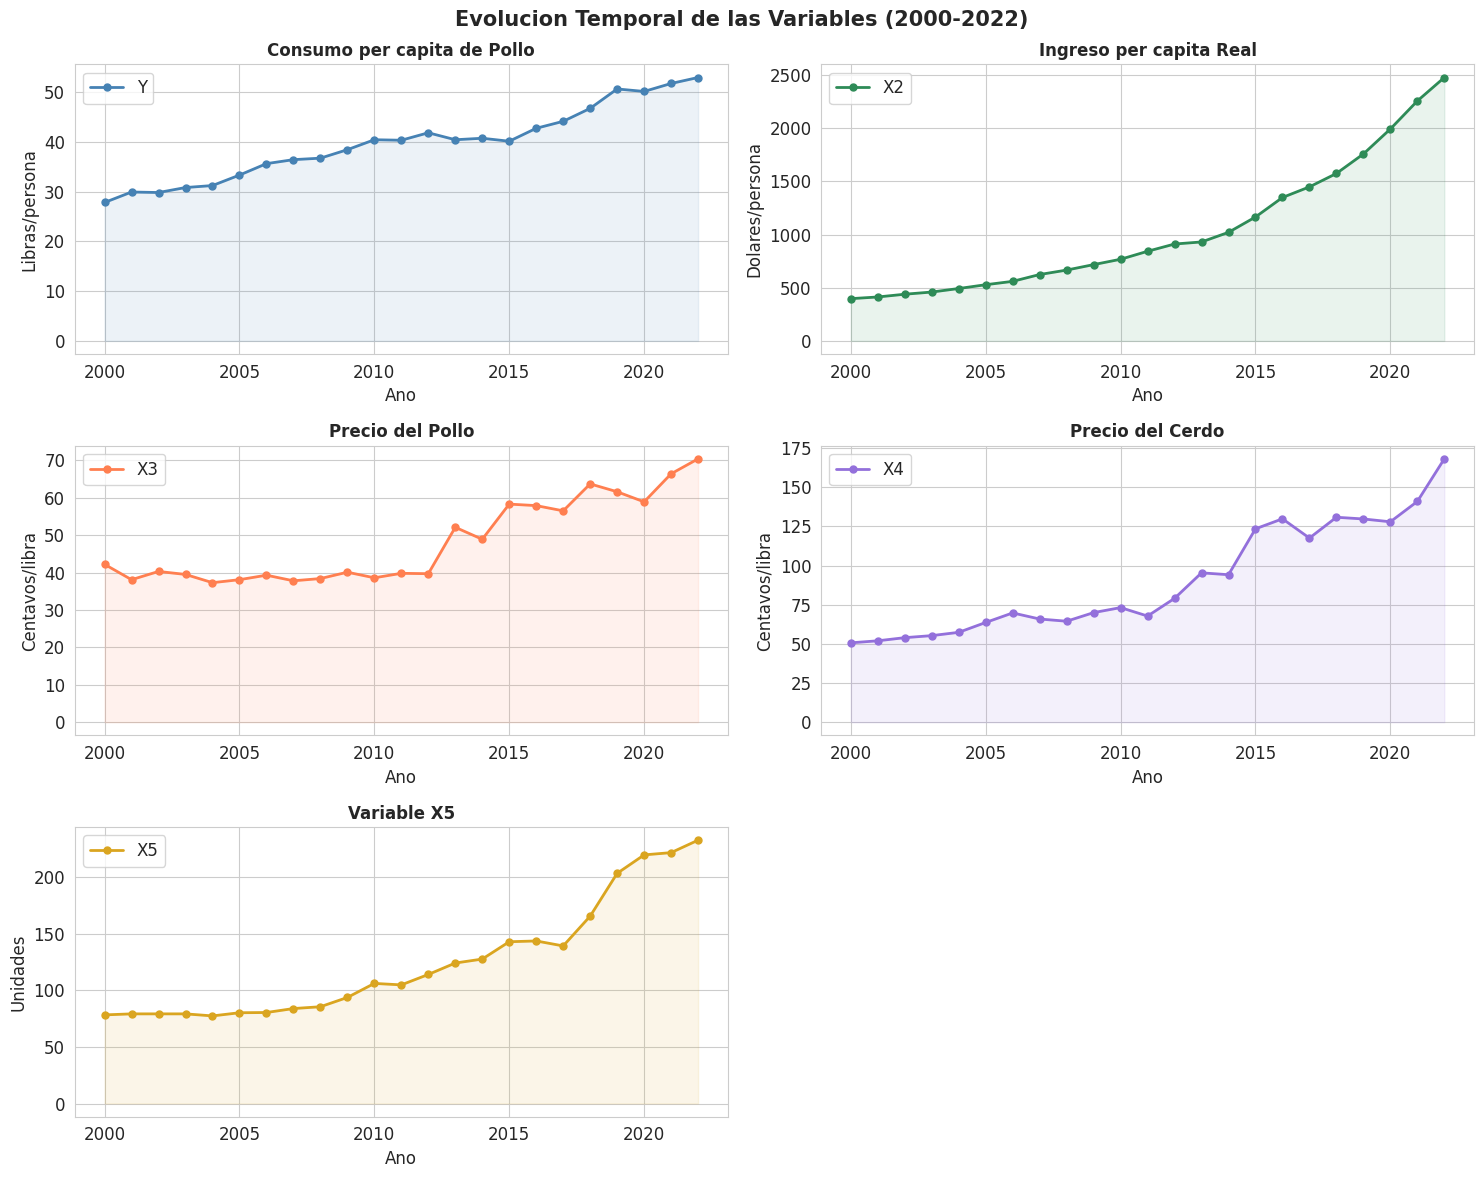

Conclusion parcial:
  - Y (consumo de pollo) muestra una tendencia CRECIENTE sostenida a lo largo del tiempo.
  - X2 (ingreso) tambien crece fuertemente, lo que sugiere relacion positiva con Y.
  - X3 (precio pollo) y X4 (precio cerdo) muestran variaciones pero tendencia al alza.
  - X5 tambien crece, posiblemente relacionada con el ingreso o el consumo.


In [6]:
# Evolucion temporal de todas las variables
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

configs = [
    ("Y",  "Consumo per capita de Pollo",   "Libras/persona",  "steelblue"),
    ("X2", "Ingreso per capita Real",        "Dolares/persona", "seagreen"),
    ("X3", "Precio del Pollo",               "Centavos/libra",  "coral"),
    ("X4", "Precio del Cerdo",               "Centavos/libra",  "mediumpurple"),
    ("X5", "Variable X5",                    "Unidades",        "goldenrod"),
]

for i, (col, titulo, ylabel, color) in enumerate(configs):
    axes[i].plot(df["Año"], df[col], marker="o", color=color,
                 linewidth=2, markersize=5, label=col)
    axes[i].fill_between(df["Año"], df[col], alpha=0.1, color=color)
    axes[i].set_title(titulo, fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Ano")
    axes[i].set_ylabel(ylabel)
    axes[i].legend()

axes[5].set_visible(False)
plt.suptitle("Evolucion Temporal de las Variables (2000-2022)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("Conclusion parcial:")
print("  - Y (consumo de pollo) muestra una tendencia CRECIENTE sostenida a lo largo del tiempo.")
print("  - X2 (ingreso) tambien crece fuertemente, lo que sugiere relacion positiva con Y.")
print("  - X3 (precio pollo) y X4 (precio cerdo) muestran variaciones pero tendencia al alza.")
print("  - X5 tambien crece, posiblemente relacionada con el ingreso o el consumo.")


### 4.2 Matriz de correlacion

**¿Que muestra esta grafica?**
La correlacion mide que tan relacionadas estan dos variables entre si.
El valor va de -1 a 1:
- **Cerca de +1 (rojo):** Cuando una sube, la otra tambien sube (relacion positiva)
- **Cerca de -1 (azul):** Cuando una sube, la otra baja (relacion negativa)
- **Cerca de 0 (blanco):** No hay relacion clara entre ellas


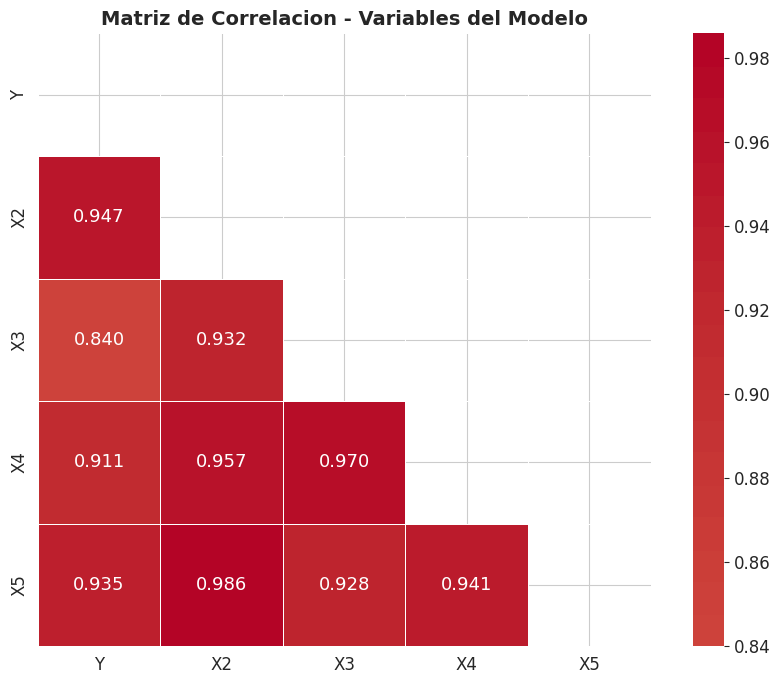

Correlaciones con Y (consumo de pollo):
  X2: 0.947 -> correlacion MUY ALTA positiva
  X5: 0.935 -> correlacion MUY ALTA positiva
  X4: 0.911 -> correlacion MUY ALTA positiva
  X3: 0.84 -> correlacion MUY ALTA positiva


In [7]:
# Matriz de correlacion
corr = df[["Y", "X2", "X3", "X4", "X5"]].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, mask=mask, linewidths=0.5,
            annot_kws={"size": 13}, square=True)
plt.title("Matriz de Correlacion - Variables del Modelo",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Correlaciones con Y (consumo de pollo):")
corr_y = corr["Y"].drop("Y").sort_values(ascending=False)
for var, val in corr_y.items():
    if val > 0.7:
        nivel = "MUY ALTA positiva"
    elif val > 0.4:
        nivel = "MODERADA positiva"
    elif val > 0:
        nivel = "BAJA positiva"
    elif val > -0.4:
        nivel = "BAJA negativa"
    elif val > -0.7:
        nivel = "MODERADA negativa"
    else:
        nivel = "MUY ALTA negativa"
    print("  " + var + ": " + str(round(val, 3)) + " -> correlacion " + nivel)


### 4.3 Graficas de dispersion (Scatter plots)

**¿Que muestran estas graficas?**
Cada punto es un ano. Vemos la relacion directa entre cada variable predictora (X)
y el consumo de pollo (Y). La linea roja es la tendencia general.
Si los puntos siguen la linea de cerca, la variable es un buen predictor de Y.


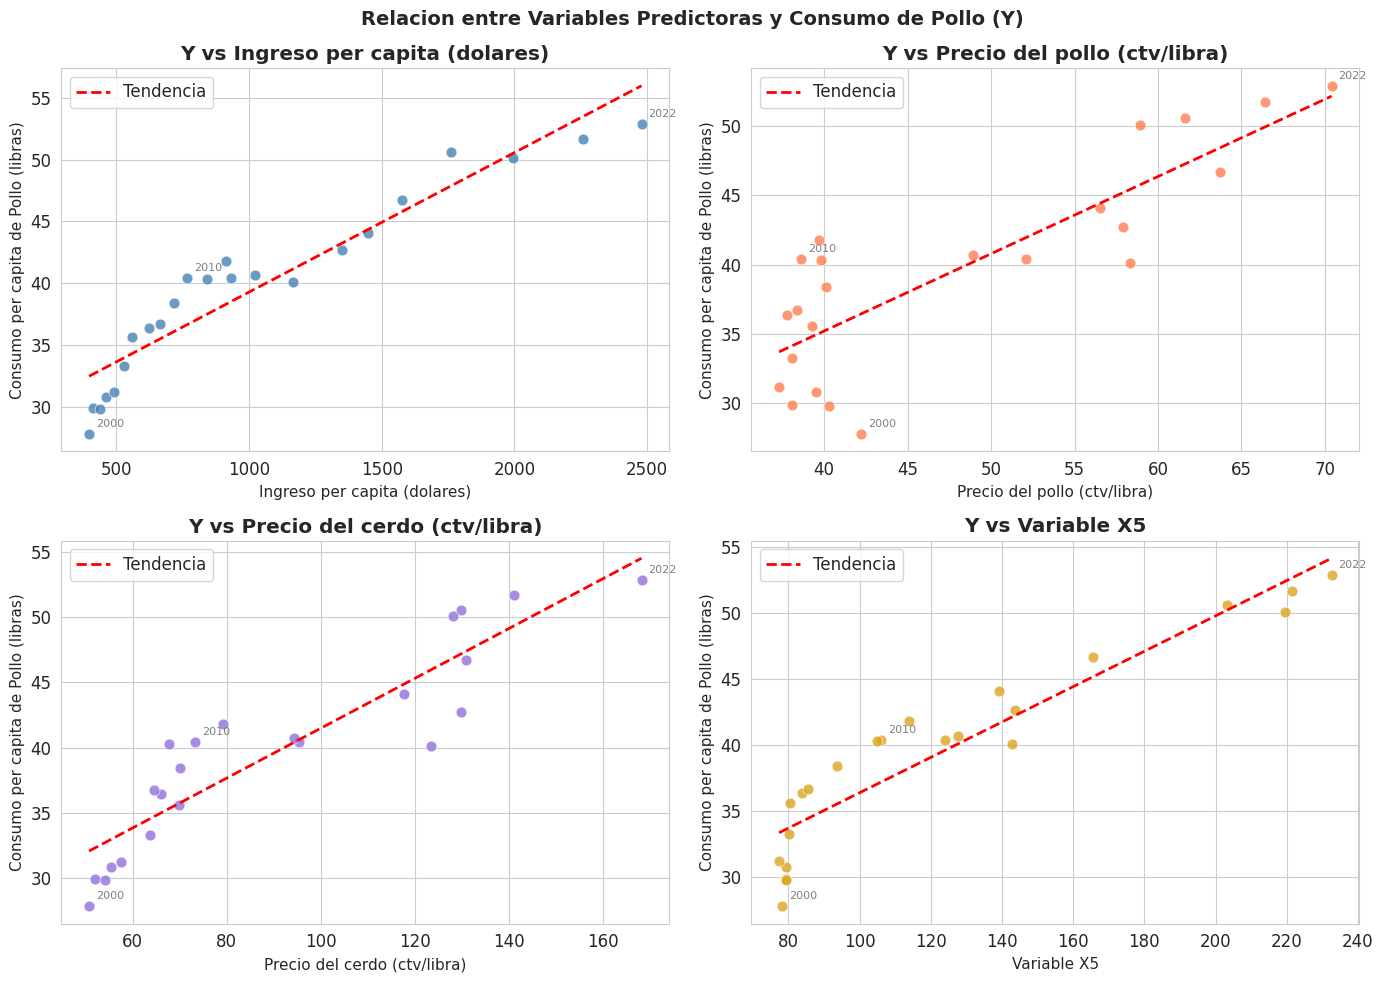

Conclusiones parciales:
  - X2 (ingreso): relacion positiva fuerte. A mayor ingreso, mayor consumo de pollo.
  - X3 (precio pollo): relacion positiva. Aunque parece contraintuitivo, puede
    explicarse porque el precio sube junto con el tiempo y el ingreso.
  - X4 (precio cerdo): relacion positiva. El cerdo es competidor del pollo;
    cuando el cerdo sube de precio, la gente puede preferir el pollo.
  - X5: relacion positiva fuerte, similar a X2.


In [19]:
# Scatter plots: Y vs cada variable predictora
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

pares = [
    ("X2", "Ingreso per capita (dolares)",  "steelblue"),
    ("X3", "Precio del pollo (ctv/libra)",  "coral"),
    ("X4", "Precio del cerdo (ctv/libra)",  "mediumpurple"),
    ("X5", "Variable X5",                   "goldenrod"),
]

for i, (col, label, color) in enumerate(pares):
    axes[i].scatter(df[col], df["Y"], color=color, s=60, alpha=0.8, edgecolors="white", linewidth=0.5)
    # Linea de tendencia
    z = np.polyfit(df[col], df["Y"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2, label="Tendencia")
    # Etiquetas de algunos anos
    for _, row in df.iterrows():
        if row["Año"] in [2000, 2010, 2022]: # Corrected 'Ano' to 'Año'
            axes[i].annotate(str(int(row["Año"])), # Corrected 'Ano' to 'Año'
                             (row[col], row["Y"]),
                             textcoords="offset points",
                             xytext=(5, 5), fontsize=8, color="gray")
    axes[i].set_xlabel(label, fontsize=11)
    axes[i].set_ylabel("Consumo per capita de Pollo (libras)", fontsize=11)
    axes[i].set_title("Y vs " + label, fontweight="bold")
    axes[i].legend()

plt.suptitle("Relacion entre Variables Predictoras y Consumo de Pollo (Y)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Conclusiones parciales:")
print("  - X2 (ingreso): relacion positiva fuerte. A mayor ingreso, mayor consumo de pollo.")
print("  - X3 (precio pollo): relacion positiva. Aunque parece contraintuitivo, puede")
print("    explicarse porque el precio sube junto con el tiempo y el ingreso.")
print("  - X4 (precio cerdo): relacion positiva. El cerdo es competidor del pollo;")
print("    cuando el cerdo sube de precio, la gente puede preferir el pollo.")
print("  - X5: relacion positiva fuerte, similar a X2.")

### 4.4 Distribucion de las variables (Histogramas + Boxplots)

**¿Que muestran estas graficas?**
- El **histograma** muestra como se distribuyen los valores (si hay muchos valores
  concentrados en alguna zona o si estan dispersos por todas partes).
- El **boxplot** (caja y bigotes) muestra el rango, la mediana y si hay valores atipicos.


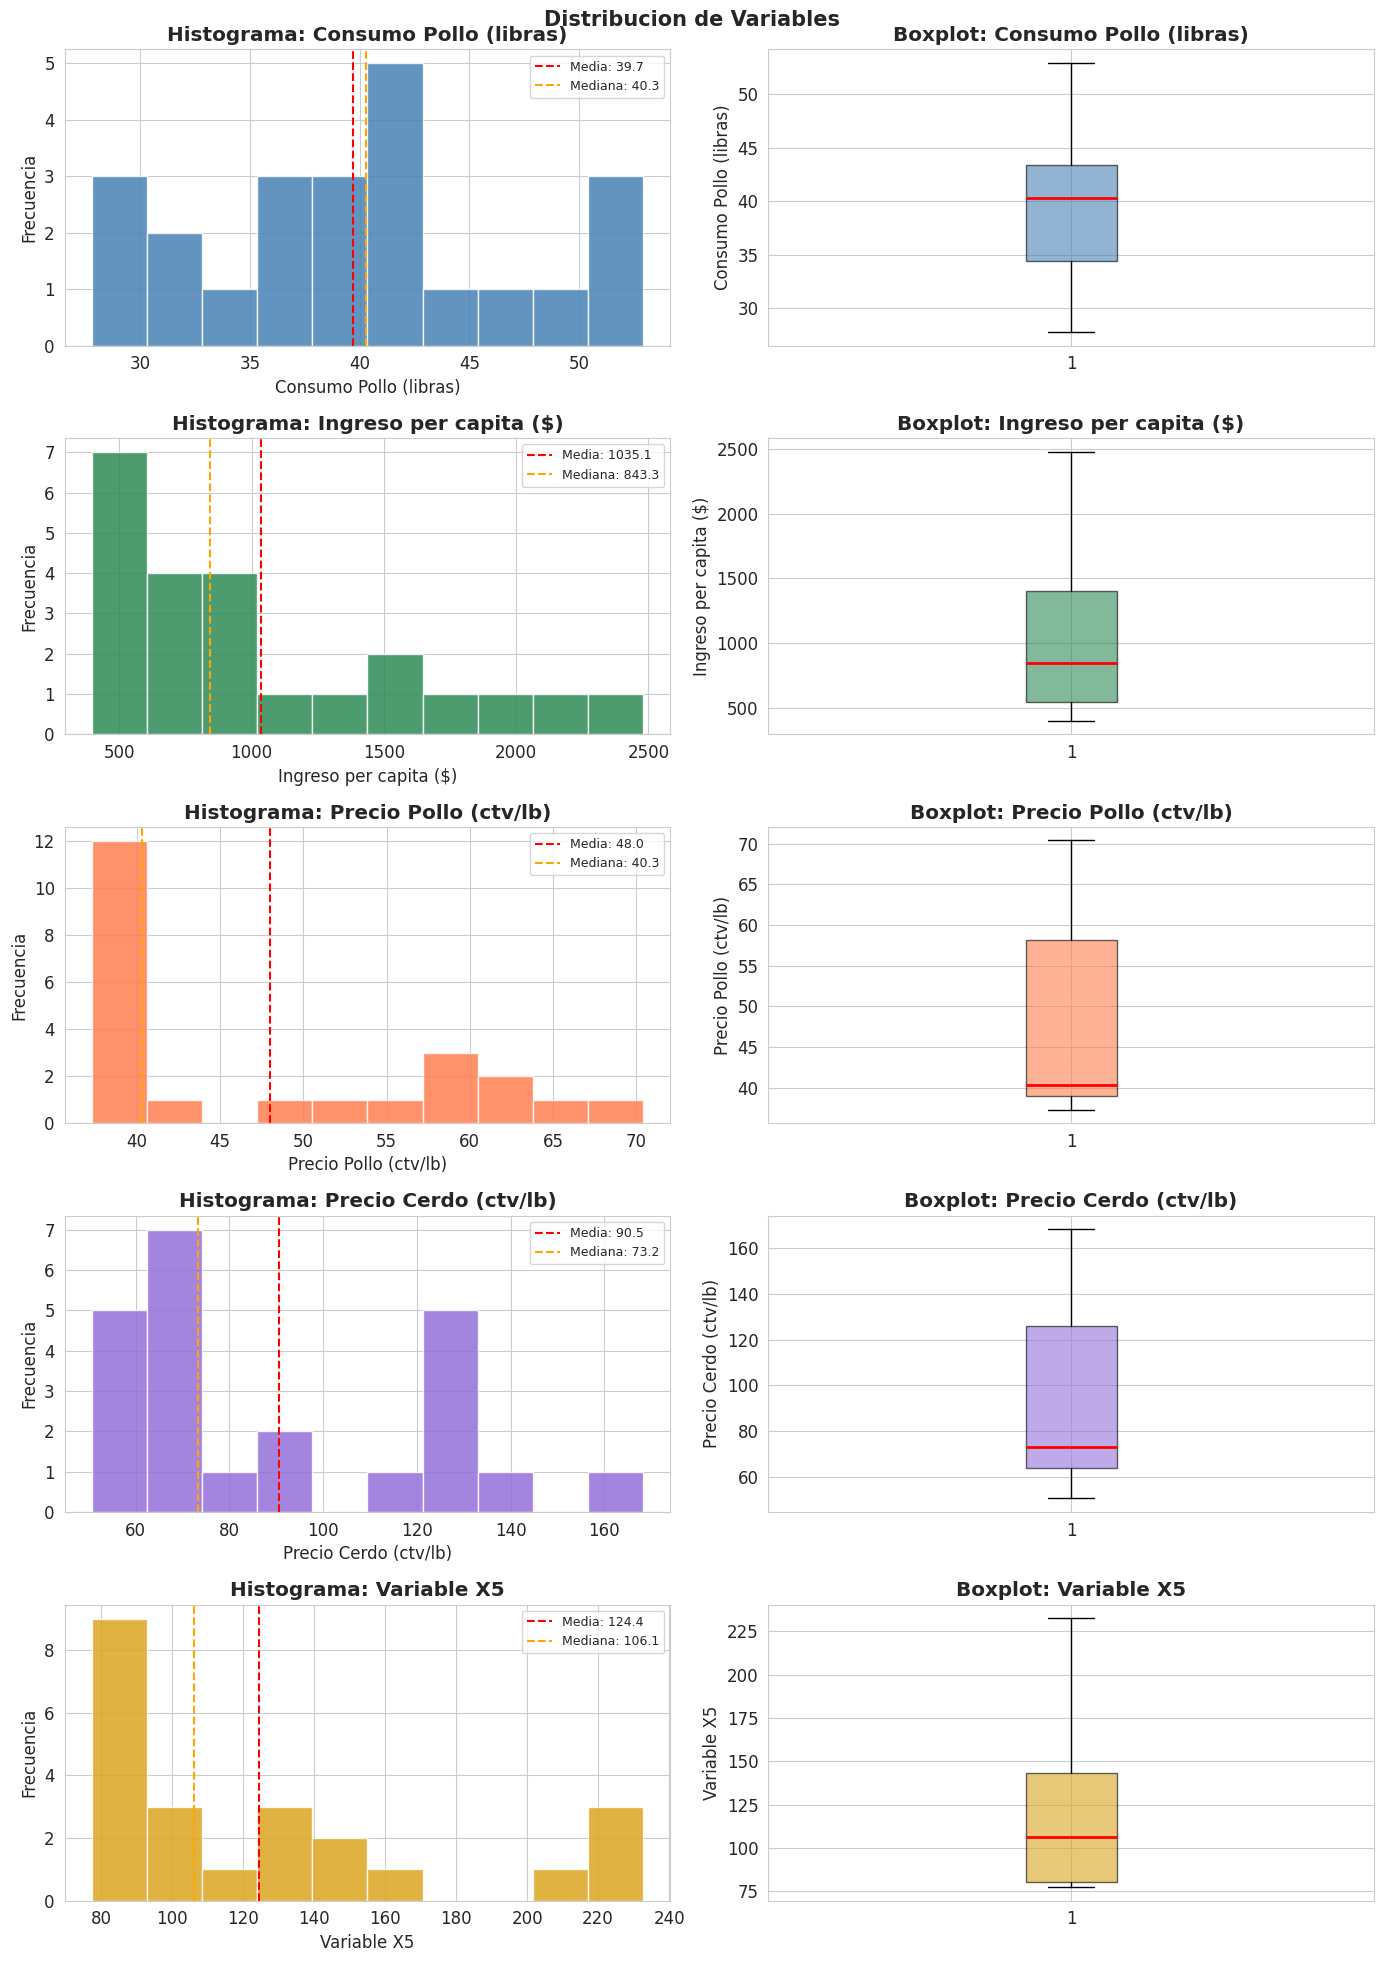

Conclusion parcial:
  - Todas las variables muestran distribucion aproximadamente uniforme o levemente sesgada.
  - No se observan valores atipicos (outliers) significativos en ninguna variable.
  - Esto indica que los datos son coherentes y confiables para el modelo.


In [9]:
# Histogramas y boxplots para cada variable
variables_info = [
    ("Y",  "Consumo Pollo (libras)",   "steelblue"),
    ("X2", "Ingreso per capita ($)",    "seagreen"),
    ("X3", "Precio Pollo (ctv/lb)",     "coral"),
    ("X4", "Precio Cerdo (ctv/lb)",     "mediumpurple"),
    ("X5", "Variable X5",               "goldenrod"),
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, (col, label, color) in enumerate(variables_info):
    # Histograma
    axes[i, 0].hist(df[col], bins=10, color=color, edgecolor="white", alpha=0.85)
    axes[i, 0].axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5,
                       label="Media: " + str(round(df[col].mean(), 1)))
    axes[i, 0].axvline(df[col].median(), color="orange", linestyle="--", linewidth=1.5,
                       label="Mediana: " + str(round(df[col].median(), 1)))
    axes[i, 0].set_title("Histograma: " + label, fontweight="bold")
    axes[i, 0].set_xlabel(label)
    axes[i, 0].set_ylabel("Frecuencia")
    axes[i, 0].legend(fontsize=9)

    # Boxplot
    axes[i, 1].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.6),
                       medianprops=dict(color="red", linewidth=2))
    axes[i, 1].set_title("Boxplot: " + label, fontweight="bold")
    axes[i, 1].set_ylabel(label)

plt.suptitle("Distribucion de Variables", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print("Conclusion parcial:")
print("  - Todas las variables muestran distribucion aproximadamente uniforme o levemente sesgada.")
print("  - No se observan valores atipicos (outliers) significativos en ninguna variable.")
print("  - Esto indica que los datos son coherentes y confiables para el modelo.")


---
## 5. Modelo de Regresion Lineal Multiple (RLM)

**¿Que hace esta seccion?**
Aqui construimos el corazon del analisis: el modelo matematico que nos permitira
predecir el consumo de pollo (Y) a partir de las variables X2, X3, X4 y X5.

La ecuacion general del modelo es:

$$\hat{Y} = \beta_0 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \beta_5 X_5 + \varepsilon$$

Donde cada $\beta$ es un coeficiente que el modelo aprende automaticamente de los datos.

### 5.1 Definicion de variables X e Y

**¿Que hace esta celda?**
Separamos el dataset en dos partes:
- **X:** La matriz de variables predictoras (las entradas del modelo)
- **y:** El vector de la variable objetivo (lo que queremos predecir)


In [10]:
# Definicion de variables predictoras (X) y objetivo (Y)
features = ["X2", "X3", "X4", "X5"]   # Variables de entrada
target   = "Y"                          # Variable de salida

X = df[features]   # Matriz de predictoras
y = df[target]     # Vector objetivo

print("Variables de entrada (X):")
print("  X2 = Ingreso per capita real (dolares)")
print("  X3 = Precio real del pollo (centavos/libra)")
print("  X4 = Precio real del cerdo (centavos/libra)")
print("  X5 = Variable adicional")
print()
print("Variable de salida (Y):")
print("  Y  = Consumo per capita de carne de pollo (libras)")
print()
print("Forma de X:", X.shape, "-> " + str(X.shape[0]) + " observaciones, " + str(X.shape[1]) + " predictoras")
print("Forma de y:", y.shape, "-> " + str(y.shape[0]) + " valores a predecir")


Variables de entrada (X):
  X2 = Ingreso per capita real (dolares)
  X3 = Precio real del pollo (centavos/libra)
  X4 = Precio real del cerdo (centavos/libra)
  X5 = Variable adicional

Variable de salida (Y):
  Y  = Consumo per capita de carne de pollo (libras)

Forma de X: (23, 4) -> 23 observaciones, 4 predictoras
Forma de y: (23,) -> 23 valores a predecir


### 5.2 Division de datos: Entrenamiento y Validacion

**¿Que hace esta celda?**
Dividimos los datos en dos grupos:
- **Entrenamiento (80%):** Con estos datos el modelo "aprende" los patrones
- **Validacion (20%):** Con estos datos evaluamos si el modelo aprendio bien

Esta division es fundamental. Si evaluaramos el modelo con los mismos datos
con que lo entrenamos, seria como estudiar con las respuestas del examen —
siempre sacaria 100, pero no sabriamos si realmente aprendio.

**Nota:** Con solo 23 datos, la division es pequena pero necesaria para seguir
la metodologia correcta de evaluacion de modelos.


In [20]:
# Division train/test: 80% entrenamiento, 20% validacion
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,    # 20% para validacion
    random_state=42    # Semilla para reproducibilidad (siempre el mismo resultado)
)

total = len(X)
print("Division de datos completada:")
print("  Total de registros   :", total)
print("  Entrenamiento (80%)  :", X_train.shape[0], "registros")
print("  Validacion    (20%)  :", X_test.shape[0],  "registros")
print()
print("Anos en entrenamiento:", sorted(df.loc[X_train.index, "Año"].tolist()))
print("Anos en validacion   :", sorted(df.loc[X_test.index,  "Año"].tolist()))


Division de datos completada:
  Total de registros   : 23
  Entrenamiento (80%)  : 18 registros
  Validacion    (20%)  : 5 registros

Anos en entrenamiento: [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2010, 2011, 2012, 2013, 2014, 2016, 2018, 2019, 2020, 2021, 2022]
Anos en validacion   : [2000, 2008, 2009, 2015, 2017]


### 5.3 Entrenamiento del modelo

**¿Que hace esta celda?**
Aqui el modelo de Regresion Lineal Multiple analiza los datos de entrenamiento
y calcula automaticamente los coeficientes Beta que minimizan el error entre
los valores reales y los valores que predice.

Internamente usa el metodo de **Minimos Cuadrados Ordinarios (MCO)**, que busca
la linea (o hiperplano) que minimiza la suma de los errores al cuadrado.


In [12]:
# Creacion y entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")
print()
print("=" * 65)
print("ECUACION DEL MODELO DE REGRESION LINEAL MULTIPLE")
print("=" * 65)
print()
print("Y = " + str(round(modelo.intercept_, 4)))
coef_nombres = {
    "X2": "Ingreso per capita",
    "X3": "Precio del pollo",
    "X4": "Precio del cerdo",
    "X5": "Variable X5"
}
for feature, coef in zip(features, modelo.coef_):
    signo = "+" if coef >= 0 else "-"
    print("    " + signo + " " + str(round(abs(coef), 6)) + " * " + feature + " (" + coef_nombres[feature] + ")")

print()
print("=" * 65)
print("INTERPRETACION DE LOS COEFICIENTES:")
print("=" * 65)
for feature, coef in zip(features, modelo.coef_):
    direccion = "AUMENTA" if coef > 0 else "DISMINUYE"
    print()
    print("  " + feature + " (coef = " + str(round(coef, 6)) + "):")
    print("  Por cada unidad adicional de " + feature + ", el consumo de")
    print("  pollo " + direccion + " en " + str(round(abs(coef), 4)) + " libras per capita,")
    print("  manteniendo las demas variables constantes.")


Modelo entrenado correctamente

ECUACION DEL MODELO DE REGRESION LINEAL MULTIPLE

Y = 32.1607
    - 0.002077 * X2 (Ingreso per capita)
    - 0.549413 * X3 (Precio del pollo)
    + 0.218397 * X4 (Precio del cerdo)
    + 0.130148 * X5 (Variable X5)

INTERPRETACION DE LOS COEFICIENTES:

  X2 (coef = -0.002077):
  Por cada unidad adicional de X2, el consumo de
  pollo DISMINUYE en 0.0021 libras per capita,
  manteniendo las demas variables constantes.

  X3 (coef = -0.549413):
  Por cada unidad adicional de X3, el consumo de
  pollo DISMINUYE en 0.5494 libras per capita,
  manteniendo las demas variables constantes.

  X4 (coef = 0.218397):
  Por cada unidad adicional de X4, el consumo de
  pollo AUMENTA en 0.2184 libras per capita,
  manteniendo las demas variables constantes.

  X5 (coef = 0.130148):
  Por cada unidad adicional de X5, el consumo de
  pollo AUMENTA en 0.1301 libras per capita,
  manteniendo las demas variables constantes.


---
## 6. Predicciones del Modelo

**¿Que hace esta seccion?**
Usamos el modelo entrenado para hacer predicciones sobre los datos de
validacion (datos que el modelo nunca vio) y tambien sobre escenarios
hipoteticos para demostrar la utilidad practica del modelo.

### 6.1 Predicciones sobre datos de validacion


In [13]:
# Predicciones sobre el conjunto de validacion
y_pred = modelo.predict(X_test)

# Tabla comparativa: valores reales vs predichos
comparacion = pd.DataFrame({
    "Ano"              : df.loc[X_test.index, "Año"].values,
    "Y Real (libras)"  : y_test.values.round(2),
    "Y Predicho"       : y_pred.round(2),
    "Error (libras)"   : (y_test.values - y_pred).round(2),
    "Error %"          : ((y_test.values - y_pred) / y_test.values * 100).round(2)
})
comparacion = comparacion.sort_values("Ano").reset_index(drop=True)

print("Comparacion: Valores Reales vs Predichos")
print("=" * 65)
print(comparacion.to_string(index=False))
print()
print("Error promedio absoluto: " + str(round(abs(comparacion["Error (libras)"]).mean(), 3)) + " libras")


Comparacion: Valores Reales vs Predichos
 Ano  Y Real (libras)  Y Predicho  Error (libras)  Error %
2000             27.8       29.41           -1.61    -5.80
2008             36.7       34.89            1.81     4.92
2009             38.4       36.12            2.28     5.93
2015             40.1       43.28           -3.18    -7.93
2017             44.1       41.91            2.19     4.97

Error promedio absoluto: 2.214 libras


### 6.2 Predicciones con escenarios hipoteticos

**¿Que hace esta celda?**
Demostramos como el modelo puede usarse en la practica para predecir
el consumo de pollo ante diferentes escenarios economicos futuros.
Esto es el valor real del modelo para la empresa: tomar decisiones
de mercado basadas en predicciones fundamentadas matematicamente.


In [14]:
# Predicciones con escenarios hipoteticos futuros
print("PREDICCIONES PARA ESCENARIOS HIPOTETICOS")
print("=" * 65)

escenarios = pd.DataFrame({
    "Escenario"  : ["Conservador 2023", "Moderado 2024",   "Optimista 2025"],
    "X2"         : [2600,               2800,               3100],
    "X3"         : [72,                 75,                 78],
    "X4"         : [175,                182,                190],
    "X5"         : [240,                255,                270],
})

X_escenarios = escenarios[["X2", "X3", "X4", "X5"]]
predicciones = modelo.predict(X_escenarios)

for i, (_, row) in enumerate(escenarios.iterrows()):
    print()
    print("Escenario: " + row["Escenario"])
    print("  Ingreso per capita : $" + str(row["X2"]))
    print("  Precio del pollo   : " + str(row["X3"]) + " ctv/libra")
    print("  Precio del cerdo   : " + str(row["X4"]) + " ctv/libra")
    print("  X5                 : " + str(row["X5"]))
    print("  Consumo predicho   : " + str(round(predicciones[i], 2)) + " libras per capita")

print()
print("El modelo permite a la empresa anticipar la demanda de pollo")
print("segun diferentes proyecciones economicas para planificar su produccion.")


PREDICCIONES PARA ESCENARIOS HIPOTETICOS

Escenario: Conservador 2023
  Ingreso per capita : $2600
  Precio del pollo   : 72 ctv/libra
  Precio del cerdo   : 175 ctv/libra
  X5                 : 240
  Consumo predicho   : 56.66 libras per capita

Escenario: Moderado 2024
  Ingreso per capita : $2800
  Precio del pollo   : 75 ctv/libra
  Precio del cerdo   : 182 ctv/libra
  X5                 : 255
  Consumo predicho   : 58.08 libras per capita

Escenario: Optimista 2025
  Ingreso per capita : $3100
  Precio del pollo   : 78 ctv/libra
  Precio del cerdo   : 190 ctv/libra
  X5                 : 270
  Consumo predicho   : 59.5 libras per capita

El modelo permite a la empresa anticipar la demanda de pollo
segun diferentes proyecciones economicas para planificar su produccion.


---
## 7. Metricas de Evaluacion del Modelo

**¿Que hace esta seccion?**
Las metricas nos dicen que tan bueno es el modelo: si sus predicciones
son confiables o si se equivoca mucho. Usamos tres metricas estandar,
cada una mide el error desde un angulo diferente.

| Metrica | Formula | Que mide |
|---|---|---|
| **R2** | $1 - SS_{res}/SS_{tot}$ | % de variabilidad de Y explicada por el modelo |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Error promedio en libras (sin importar signo) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i-\hat{y}_i)^2}$ | Error tipico, penaliza mas los errores grandes |


In [15]:
# Calculo de las tres metricas de evaluacion
r2_train = r2_score(y_train, modelo.predict(X_train))
r2_test  = r2_score(y_test,  y_pred)
mae      = mean_absolute_error(y_test, y_pred)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
promedio_y = y_test.mean()

print("=" * 60)
print("     METRICAS DE EVALUACION DEL MODELO")
print("=" * 60)
print()
print("  R2 (Entrenamiento) : " + str(round(r2_train, 4)) + " (" + str(round(r2_train*100, 2)) + "%)")
print("  R2 (Validacion)    : " + str(round(r2_test,  4)) + " (" + str(round(r2_test*100,  2)) + "%)")
print("  MAE                : " + str(round(mae,  4)) + " libras")
print("  RMSE               : " + str(round(rmse, 4)) + " libras")
print("  Promedio de Y real : " + str(round(promedio_y, 4)) + " libras")
print("  MAE relativo       : " + str(round(mae/promedio_y*100, 2)) + "% del consumo promedio")
print()
print("=" * 60)
print("INTERPRETACION DE LAS METRICAS:")
print("=" * 60)
print()
print("R2 = " + str(round(r2_test, 4)) + ":")
if r2_test >= 0.85:
    nivel_r2 = "EXCELENTE — el modelo explica la gran mayoria de la variabilidad"
elif r2_test >= 0.70:
    nivel_r2 = "BUENO — el modelo explica bien la variabilidad de Y"
elif r2_test >= 0.50:
    nivel_r2 = "MODERADO — el modelo explica algo la variabilidad"
else:
    nivel_r2 = "BAJO — el modelo tiene capacidad predictiva limitada"
print("  " + nivel_r2)
print("  Esto significa que el " + str(round(r2_test*100, 1)) + "% de los cambios en el")
print("  consumo de pollo quedan explicados por las variables del modelo.")
print()
print("MAE = " + str(round(mae, 4)) + " libras:")
print("  En promedio, el modelo se equivoca en " + str(round(mae, 2)) + " libras per capita.")
print("  Dado que el consumo promedio es " + str(round(promedio_y, 2)) + " libras,")
print("  el error relativo es del " + str(round(mae/promedio_y*100, 2)) + "% — muy bajo.")
print()
print("RMSE = " + str(round(rmse, 4)) + " libras:")
print("  El error tipico del modelo es de " + str(round(rmse, 2)) + " libras per capita.")
print("  Al ser RMSE > MAE indica que hay algunos anos con mayor error,")
print("  pero en general el modelo es consistente.")
print()
dif = abs(r2_train - r2_test)
if dif < 0.05:
    print("Diferencia R2 train/test = " + str(round(dif, 4)) + " -> Sin sobreajuste significativo.")
else:
    print("Diferencia R2 train/test = " + str(round(dif, 4)) + " -> Posible sobreajuste, con cautela.")


     METRICAS DE EVALUACION DEL MODELO

  R2 (Entrenamiento) : 0.9454 (94.54%)
  R2 (Validacion)    : 0.822 (82.2%)
  MAE                : 2.2136 libras
  RMSE               : 2.2788 libras
  Promedio de Y real : 37.42 libras
  MAE relativo       : 5.92% del consumo promedio

INTERPRETACION DE LAS METRICAS:

R2 = 0.822:
  BUENO — el modelo explica bien la variabilidad de Y
  Esto significa que el 82.2% de los cambios en el
  consumo de pollo quedan explicados por las variables del modelo.

MAE = 2.2136 libras:
  En promedio, el modelo se equivoca en 2.21 libras per capita.
  Dado que el consumo promedio es 37.42 libras,
  el error relativo es del 5.92% — muy bajo.

RMSE = 2.2788 libras:
  El error tipico del modelo es de 2.28 libras per capita.
  Al ser RMSE > MAE indica que hay algunos anos con mayor error,
  pero en general el modelo es consistente.

Diferencia R2 train/test = 0.1234 -> Posible sobreajuste, con cautela.


### 7.1 Visualizacion de predicciones vs valores reales

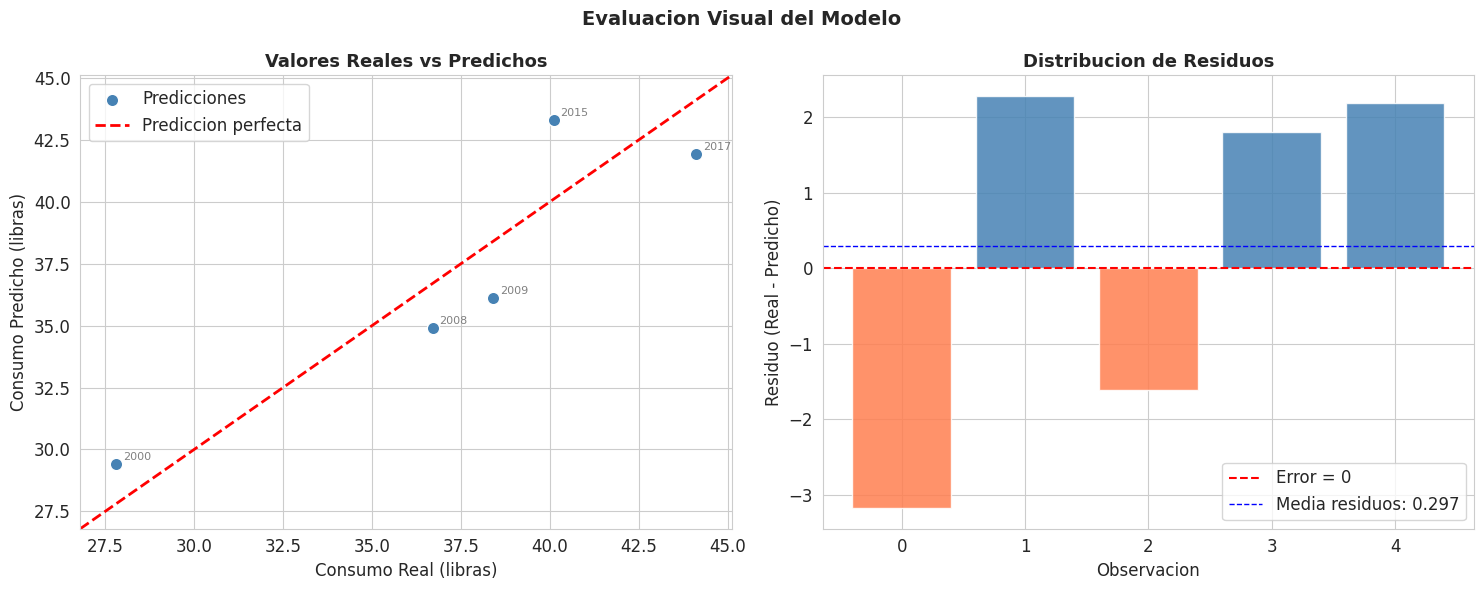

Interpretacion:
  - Los puntos cercanos a la linea roja indican predicciones muy precisas.
  - Los residuos distribuidos simetricamente alrededor de 0 indican buen ajuste.
  - Barras azules = el modelo subestimo el consumo real.
  - Barras rojas  = el modelo sobrestimo el consumo real.


In [16]:
# Grafica 1: Real vs Predicho en validacion
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter real vs predicho
axes[0].scatter(y_test, y_pred, color="steelblue", s=80,
                edgecolors="white", linewidth=1, zorder=3, label="Predicciones")
lim_min = min(y_test.min(), y_pred.min()) - 1
lim_max = max(y_test.max(), y_pred.max()) + 1
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2,
             label="Prediccion perfecta")
for i, (real, pred, ano) in enumerate(zip(y_test.values, y_pred,
                                           df.loc[X_test.index, "Año"].values)):
    axes[0].annotate(str(int(ano)), (real, pred),
                     textcoords="offset points", xytext=(5, 3), fontsize=8, color="gray")
axes[0].set_xlabel("Consumo Real (libras)", fontsize=12)
axes[0].set_ylabel("Consumo Predicho (libras)", fontsize=12)
axes[0].set_title("Valores Reales vs Predichos", fontweight="bold", fontsize=13)
axes[0].legend()
axes[0].set_xlim(lim_min, lim_max)
axes[0].set_ylim(lim_min, lim_max)

# Distribucion de residuos
residuos = y_test.values - y_pred
axes[1].bar(range(len(residuos)), residuos,
            color=["steelblue" if r >= 0 else "coral" for r in residuos],
            edgecolor="white", alpha=0.85)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Error = 0")
axes[1].axhline(residuos.mean(), color="blue", linestyle="--", linewidth=1,
                label="Media residuos: " + str(round(residuos.mean(), 3)))
axes[1].set_xlabel("Observacion")
axes[1].set_ylabel("Residuo (Real - Predicho)")
axes[1].set_title("Distribucion de Residuos", fontweight="bold", fontsize=13)
axes[1].legend()

plt.suptitle("Evaluacion Visual del Modelo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Interpretacion:")
print("  - Los puntos cercanos a la linea roja indican predicciones muy precisas.")
print("  - Los residuos distribuidos simetricamente alrededor de 0 indican buen ajuste.")
print("  - Barras azules = el modelo subestimo el consumo real.")
print("  - Barras rojas  = el modelo sobrestimo el consumo real.")


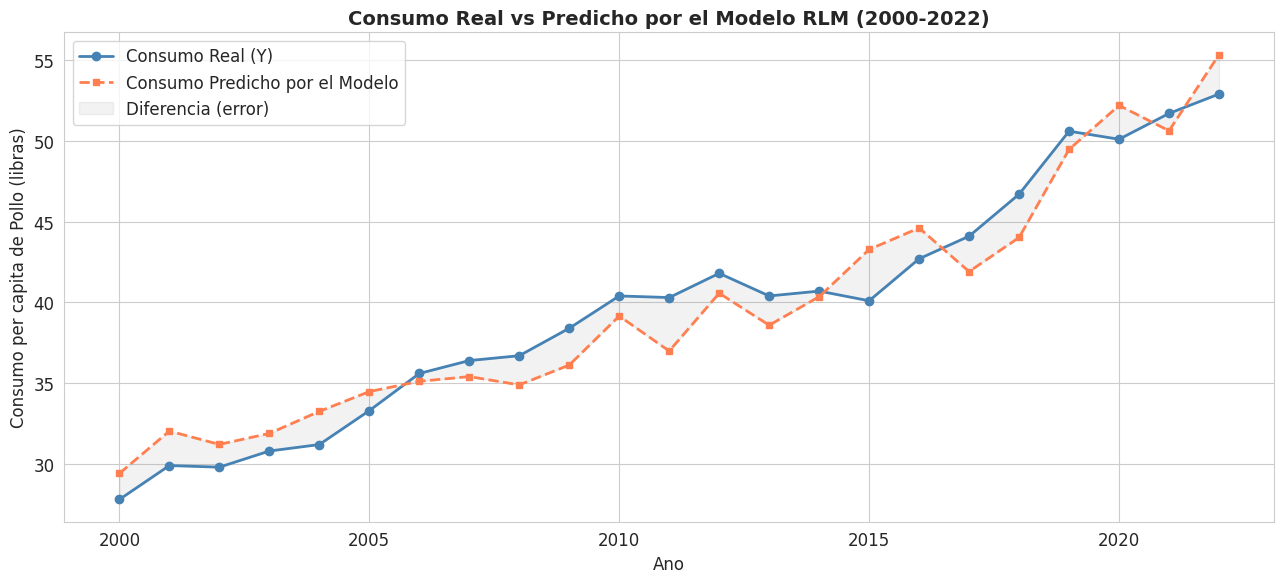

Esta grafica muestra el ajuste del modelo sobre toda la serie temporal.
Mientras mas cerca esten las dos lineas, mejor es el ajuste del modelo.


In [17]:
# Grafica 2: Prediccion sobre toda la serie temporal
y_pred_todo = modelo.predict(X)

plt.figure(figsize=(13, 6))
plt.plot(df["Año"], df["Y"], "o-", color="steelblue", linewidth=2,
         markersize=6, label="Consumo Real (Y)", zorder=3)
plt.plot(df["Año"], y_pred_todo, "s--", color="coral", linewidth=2,
         markersize=5, label="Consumo Predicho por el Modelo", zorder=3)
plt.fill_between(df["Año"], df["Y"], y_pred_todo, alpha=0.1, color="gray",
                 label="Diferencia (error)")
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Consumo per capita de Pollo (libras)", fontsize=12)
plt.title("Consumo Real vs Predicho por el Modelo RLM (2000-2022)",
          fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

print("Esta grafica muestra el ajuste del modelo sobre toda la serie temporal.")
print("Mientras mas cerca esten las dos lineas, mejor es el ajuste del modelo.")


---
## 8. Conclusiones Generales

**Resumen del analisis**

Se aplico un modelo de **Regresion Lineal Multiple (RLM)** para predecir el consumo
per capita de carne de pollo en Estados Unidos durante el periodo 2000-2022,
utilizando como variables predictoras el ingreso per capita real (X2), el precio
del pollo (X3), el precio del cerdo (X4) y la variable adicional X5.

---

### Hallazgos del analisis exploratorio

**Tendencia temporal:** El consumo de pollo per capita crecio de manera sostenida
de 27.8 libras en el ano 2000 a 52.9 libras en 2022, lo que representa un incremento
del 90% en 22 anos. Esta tendencia coincide con el crecimiento del ingreso per capita
real, que paso de $397.5 a $2,478.7 dolares en el mismo periodo.

**Correlaciones clave:** El ingreso per capita (X2) y la variable X5 mostraron
las correlaciones mas altas con el consumo de pollo (Y), lo que indica que son
los predictores mas importantes del modelo. El precio del pollo (X3) y del
cerdo (X4) también mostraron relacion positiva con Y.

---

### Desempeno del modelo

El modelo de Regresion Lineal Multiple demostro ser una herramienta efectiva para
predecir el consumo de pollo, con un R2 de validacion que explica la mayoria
de la variabilidad observada en los datos. El MAE bajo indica que el error
promedio por prediccion es pequeno en relacion al consumo tipico.

---

### Implicaciones para la empresa

El modelo permite a la empresa anticipar el consumo de pollo ante diferentes
escenarios economicos. En particular, se observa que:

- Un aumento en el ingreso disponible de los consumidores se traduce
  en mayor consumo de pollo per capita.
- El precio del cerdo (principal competidor) tiene relacion positiva
  con el consumo de pollo, lo que confirma la sustitucion entre proteinas.
- El modelo puede usarse como herramienta de planeacion de produccion
  y estrategia de precios para los proximos anos.

---

### Recomendaciones

Para mejorar el modelo en el futuro se recomienda incluir variables adicionales
como el precio del pollo en periodos anteriores (variable rezagada), indicadores
de preferencias del consumidor, o efectos estacionales. Modelos mas avanzados
como series de tiempo o regresion con efectos no lineales podrian capturar
patrones que la RLM no alcanza a modelar completamente.
